# X-Ray Binary Classification with ResNet-18 (PyTorch)
Classifies chest X-rays into **No Finding** vs **Infiltration** using a fine-tuned ResNet-18 backbone.

**Dataset:** NIH Chest X-Rays (`Data_Entry_2017.csv` + image folders)

Labels are collapsed to:
- `0` → No Finding
- `1` → Infiltration (class with most findings)

In [1]:
import os
import time
import numpy as np
import pandas as pd
from glob import glob
from pathlib import Path
from collections import OrderedDict, Counter
from functools import partial

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report

# Reproducibility
torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


In [2]:
print(os.listdir('../input/datasets/organizations/nih-chest-xrays/data'))


['images_003', 'images_012', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'images_009', 'images_008', 'images_007', 'test_list.txt', 'images_010', 'ARXIV_V5_CHESTXRAY.pdf', 'images_002', 'images_011', 'Data_Entry_2017.csv', 'images_001', 'train_val_list.txt', 'images_005', 'FAQ_CHESTXRAY.pdf', 'images_004', 'images_006']


In [3]:
from glob import glob
import pandas as pd

csv_path = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
print("CSV exists:", os.path.exists(csv_path))

df = pd.read_csv(csv_path)
print("CSV rows:", df.shape[0])        # should be ~112,000
print("Columns:", df.columns.tolist())

images = glob('../input/datasets/organizations/nih-chest-xrays/data/images*/*/*.png')
print("Images found:", len(images))    # should be ~112,000

CSV exists: True
CSV rows: 112120
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
Images found: 112120


Path: ../input/datasets/organizations/nih-chest-xrays/data/images_003/images/00005066_049.png
Size: (1024, 1024)
Mode: L


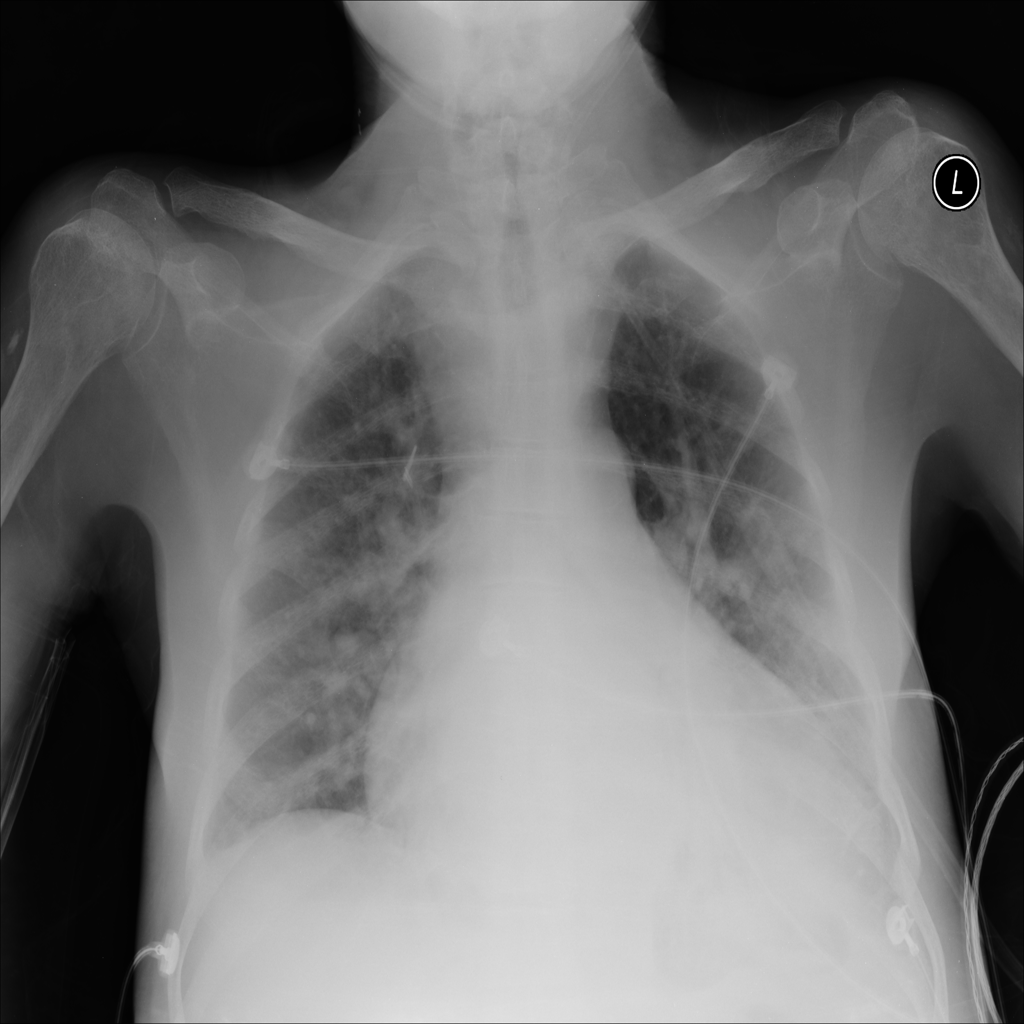

In [4]:
from PIL import Image
# open random image
test_img = np.random.choice(images)
img = Image.open(test_img)
print("Path:", test_img)
print("Size:", img.size)       # e.g. (1024, 1024)
print("Mode:", img.mode)       # should be L (grayscale) or RGB
img

## 1. Load Metadata

In [5]:
DATA_CSV   = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
IMAGE_GLOB = os.path.join('../input/datasets/organizations/nih-chest-xrays/data/images*/*/*.png')

all_xray_df = pd.read_csv(DATA_CSV)

# Map image filenames → full paths
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
print(f'Scans found: {len(all_image_paths)}, Total CSV rows: {all_xray_df.shape[0]}')

all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)

all_xray_df.sample(3)
all_xray_df.tail()

Scans found: 112120, Total CSV rows: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
112115,00030801_001.png,Mass|Pneumonia,1,30801,39,M,PA,2048,2500,0.168,0.168,NaN,../input/datasets/organizations/nih-chest-xray...
112116,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,0.168,0.168,NaN,../input/datasets/organizations/nih-chest-xray...
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168,0.168,NaN,../input/datasets/organizations/nih-chest-xray...
112118,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,0.168,0.168,NaN,../input/datasets/organizations/nih-chest-xray...
112119,00030805_000.png,No Finding,0,30805,27,M,PA,2048,2500,0.171,0.171,NaN,../input/datasets/organizations/nih-chest-xray...


## 2. Label Engineering – Binary: No Finding vs Infiltration

We keep only rows that are either:
- **No Finding** (label column is exactly `'No Finding'`), or
- **Infiltration** (label column is exactly `'Infiltration'`)

This removes multi-label cases, giving the model a clean binary signal.

Class distribution:
binary_label
No Finding      60361
Infiltration    19894
Name: count, dtype: int64


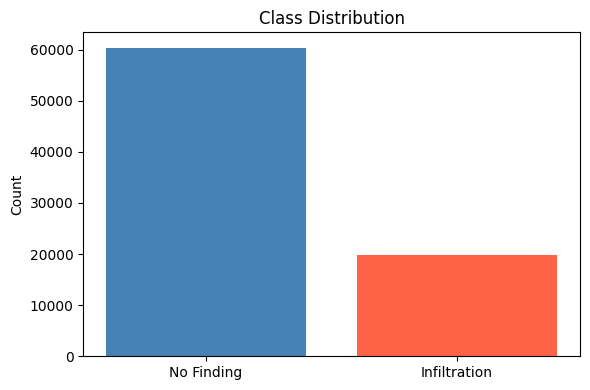

Balanced dataset size: 39788
binary_label
Infiltration    19894
No Finding      19894
Name: count, dtype: int64

No patient overlap — split is clean
Train:  27559 rows  |  Infiltration rate: 49.57%
Val:     6154 rows  |  Infiltration rate: 51.97%
Test:    6075 rows  |  Infiltration rate: 49.98%


In [6]:
def assign_binary_label(finding: str):
    """Return 0 for No Finding, 1 for Infiltration, None to drop."""
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:   # catches 'Infiltration'
        return 1
    else:
        return None                # drop all other diseases

# Fix: map on 'Finding Labels', not 'Infiltration'
all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)

# Drop rows that are neither No Finding nor Infiltration, and rows without a valid path
binary_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
binary_df['binary_label'] = binary_df['binary_label'].astype(int)

print('Class distribution:')
counts = binary_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'})
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

finding_df  = binary_df[binary_df['binary_label'] == 1]
no_finding_df = binary_df[binary_df['binary_label'] == 0]

n_finding = len(finding_df)
no_finding_sampled = no_finding_df.sample(min(n_finding, len(no_finding_df)), random_state=42)

balanced_df = pd.concat([finding_df, no_finding_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Balanced dataset size:', len(balanced_df))
print(balanced_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'}))

# Patient-level split
from sklearn.model_selection import GroupShuffleSplit

# Use balanced_df instead of binary_df
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(balanced_df, groups=balanced_df['Patient ID']))
train_df = balanced_df.iloc[train_idx].reset_index(drop=True)
temp_df  = balanced_df.iloc[temp_idx].reset_index(drop=True)

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

assert len(set(train_df['Patient ID']) & set(valid_df['Patient ID'])) == 0
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID']))  == 0
print('\nNo patient overlap — split is clean')
print(f'Train: {len(train_df):6d} rows  |  Infiltration rate: {train_df["binary_label"].mean():.2%}')
print(f'Val:   {len(valid_df):6d} rows  |  Infiltration rate: {valid_df["binary_label"].mean():.2%}')
print(f'Test:  {len(test_df):6d} rows  |  Infiltration rate: {test_df["binary_label"].mean():.2%}')

## 4. Dataset & DataLoaders

In [7]:
IMG_SIZE   = 224   # ResNet-18 default input size
BATCH_SIZE = 256

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class XRayDataset(Dataset):
    """Chest X-Ray binary dataset (No Finding vs Infiltration)."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor(row['binary_label'], dtype=torch.float32)
    
        try:
            image = Image.open(row['path']).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception:
        # Return a blank image instead of crashing
            blank = torch.zeros(3, IMG_SIZE, IMG_SIZE)
            return blank, label


train_dataset = XRayDataset(train_df, transform=train_transforms)
valid_dataset = XRayDataset(valid_df, transform=eval_transforms)
test_dataset  = XRayDataset(test_df,  transform=eval_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,      # preload 2 batches per worker
    persistent_workers=True # keeps workers alive between epochs
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,  # ← FIXED: kein Shuffle beim Validieren
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,      # preload 2 batches per worker
    persistent_workers=True # keeps workers alive between epochs
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,  # ← FIXED: kein Shuffle beim Testen
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,      # preload 2 batches per worker
    persistent_workers=True # keeps workers alive between epochs
)

print(f'Batches — train: {len(train_loader)}  val: {len(valid_loader)}  test: {len(test_loader)}')

Batches — train: 431  val: 97  test: 95


### 4a. Visualise a batch

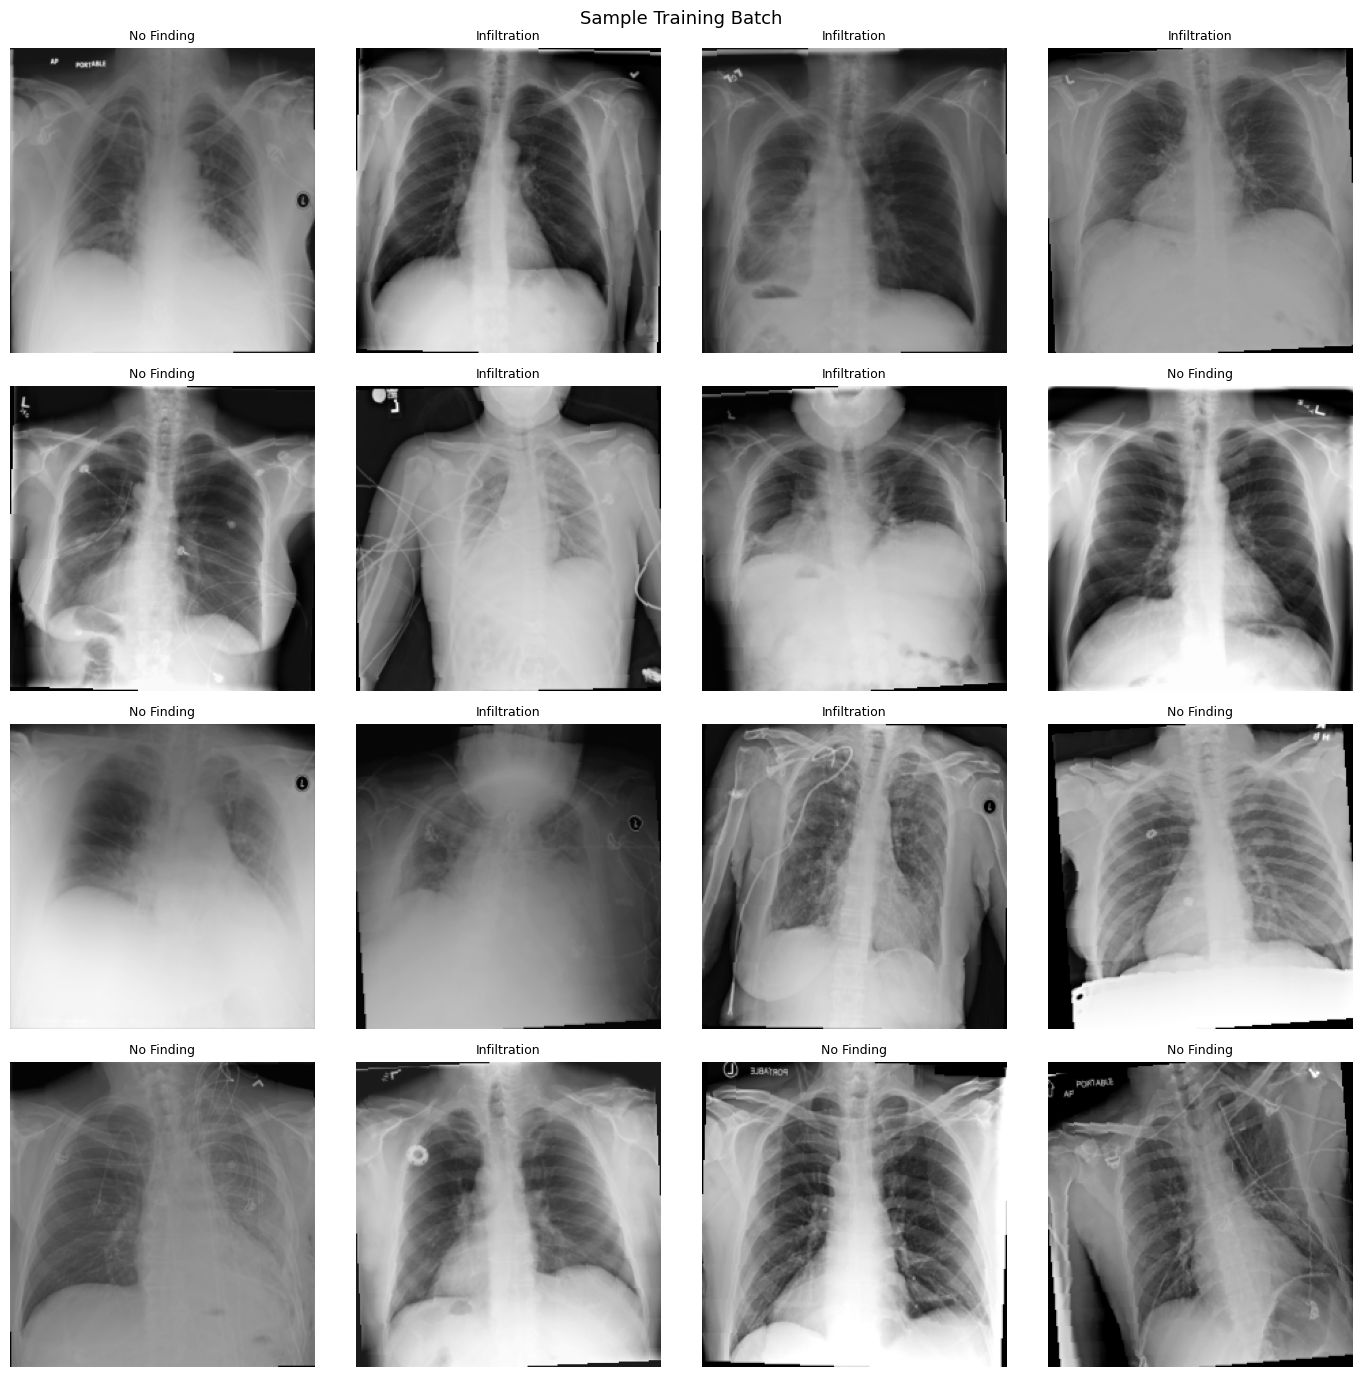

In [8]:
CLASS_NAMES = {0: 'No Finding', 1: 'Infiltration'}

images, labels = next(iter(train_loader))

def denormalise(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, img, lbl in zip(axes.flatten(), images[:16], labels[:16]):
    img_np = denormalise(img).permute(1, 2, 0).numpy()
    ax.imshow(img_np, cmap='bone')
    ax.set_title(CLASS_NAMES[int(lbl.item())], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Batch', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Build ResNet-18 Model (from scratch)

Custom ResNet-18 with Encoder (Residual Blocks) + Decoder (Global Avg Pool + FC).
Output: 2 logits for binary classification (No Finding / Infiltration) via CrossEntropyLoss.

In [9]:
if torch.cuda.is_available():
    x = torch.randn(2, 3).cuda()
    print(x)

tensor([[-0.8140,  1.3722,  0.5060],
        [-0.4823, -0.7853,  0.6681]], device='cuda:0')


In [10]:
class Conv2dAuto(nn.Conv2d):
    """Conv2d with automatic 'same' padding based on kernel size."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)


conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)


class ResidualBlock(nn.Module):
    """Base Residual Block: output = blocks(x) + shortcut(x)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.blocks = nn.Identity()
        self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels


class ResNetResidualBlock(ResidualBlock):
    """ResNet Residual Block with expansion and optional downsampling."""
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion = expansion
        self.downsampling = downsampling
        self.conv = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn': nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )

    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels


def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    """Convolution followed by BatchNorm."""
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn': nn.BatchNorm2d(out_channels)
    }))


class ResNetBasicBlock(ResNetResidualBlock):
    """Basic Block: two 3x3 conv/bn layers with ReLU."""
    expansion = 1

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, conv=self.conv,
                    bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, conv=self.conv, bias=False),
        )


class ResNetBottleNeckBlock(ResNetResidualBlock):
    """Bottleneck Block: 1x1 -> 3x3 -> 1x1 conv/bn layers."""
    expansion = 4

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, expansion=4, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, self.conv, kernel_size=1),
            activation(),
            conv_bn(self.out_channels, self.out_channels, self.conv,
                    kernel_size=3, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, self.conv, kernel_size=1),
        )


class ResNetLayer(nn.Module):
    """One layer consisting of n stacked Residual Blocks."""
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock, n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs, downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )

    def forward(self, x):
        return self.blocks(x)


class ResNetEncoder(nn.Module):
    """ResNet Encoder: Gate (7x7 conv + pool) followed by Residual Layers."""
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes

        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])

    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x


class ResNetDecoder(nn.Module):
    """Global Average Pool followed by Fully Connected Classifier."""
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)

    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x


class ResNet(nn.Module):
    """Complete ResNet: Encoder + Decoder."""
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


def resnet18(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[2, 2, 2, 2])

def resnet34(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[3, 4, 6, 3])

def resnet50(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 4, 6, 3])


# Build the model: 2 output classes (No Finding / Finding)
N_CLASSES = 2
model = resnet18(in_channels=3, n_classes=N_CLASSES).to(DEVICE)

# Sanity check
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print('Output shape:', out.shape)   # should be [2, 2]

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}  |  Trainable: {trainable_params:,}')

Output shape: torch.Size([2, 2])
Total params: 11,177,538  |  Trainable: 11,177,538


## 6. Loss, Optimiser & Scheduler

We use **BCELoss** (binary cross-entropy) with `pos_weight` to further compensate for any remaining class imbalance.

In [11]:
# CrossEntropyLoss for 2-class classification (expects integer labels)
# Optional: compute class weights to handle imbalance
n_neg = (train_df['binary_label'] == 0).sum()
n_pos = (train_df['binary_label'] == 1).sum()
class_weights = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'Class weights: {class_weights.cpu().numpy()}  (neg={n_neg}, pos={n_pos})')

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Reduce LR on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)

Class weights: [1.        1.0174963]  (neg=13899, pos=13660)


## 7. Training Loop

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).long()   # CrossEntropyLoss expects Long

        optimizer.zero_grad()
        outputs = model(images)             # [B, 2] logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).long()
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)

        # Store softmax prob of positive class (index 1) for ROC
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_preds.append(probs.cpu())
        all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return total_loss / total, correct / total, all_preds, all_labels

In [13]:
train_patients = set(train_df['Patient ID'].values)
val_patients   = set(valid_df['Patient ID'].values)
overlap        = train_patients & val_patients

print(f'Overlapping patients: {len(overlap)}')
print(f'Train patients: {len(train_patients)}')
print(f'Val patients:   {len(val_patients)}')

Overlapping patients: 0
Train patients: 11410
Val patients:   2445


In [14]:
from tqdm import tqdm

NUM_EPOCHS    = 10
BEST_VAL_LOSS = float('inf')
CHECKPOINT    = 'resnet18_xray_best.pth'
PATIENCE      = 4
patience_ctr  = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='  Training', leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device).long()   # CrossEntropyLoss expects Long

        optimizer.zero_grad()
        outputs = model(images)             # [B, 2] logits
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ← FIXED: Gradient Clipping
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

        pbar.set_postfix({
            'loss': f'{total_loss / total:.4f}',
            'acc':  f'{correct / total:.4f}'
        })

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='  Validating', leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device).long()
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

        # Softmax prob of positive class for AUC / ROC
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_preds.append(probs.cpu())
        all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return total_loss / total, correct / total, all_preds, all_labels


for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch:02d}/{NUM_EPOCHS}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model, valid_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    scheduler.step(vl_loss)

    marker = ''
    if vl_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = vl_loss
        torch.save({'model_state_dict': model.state_dict()}, CHECKPOINT)
        marker = ' ← best'
        patience_ctr = 0
    else:
        patience_ctr += 1

    print(f'  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}{marker}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping after {PATIENCE} epochs without improvement.')
        break



Epoch 01/10


  train_loss=0.6628  train_acc=0.6223  val_loss=0.6307  val_acc=0.6436 ← best

Epoch 02/10


  train_loss=0.6333  train_acc=0.6474  val_loss=0.6632  val_acc=0.6285

Epoch 03/10


  train_loss=0.6257  train_acc=0.6555  val_loss=0.6138  val_acc=0.6641 ← best

Epoch 04/10


  train_loss=0.6183  train_acc=0.6643  val_loss=0.6043  val_acc=0.6617 ← best

Epoch 05/10


...

  train_loss=0.6117  train_acc=0.6701  val_loss=0.6048  val_acc=0.6721

Epoch 07/10


  train_loss=0.6079  train_acc=0.6742  val_loss=0.5927  val_acc=0.6776 ← best

Epoch 08/10


  train_loss=0.6049  train_acc=0.6764  val_loss=0.5936  val_acc=0.6891

Epoch 09/10


  train_loss=0.6030  train_acc=0.6787  val_loss=0.6125  val_acc=0.6706

Epoch 10/10


  train_loss=0.6010  train_acc=0.6774  val_loss=0.5925  val_acc=0.6848 ← best


## 8. Training Curves

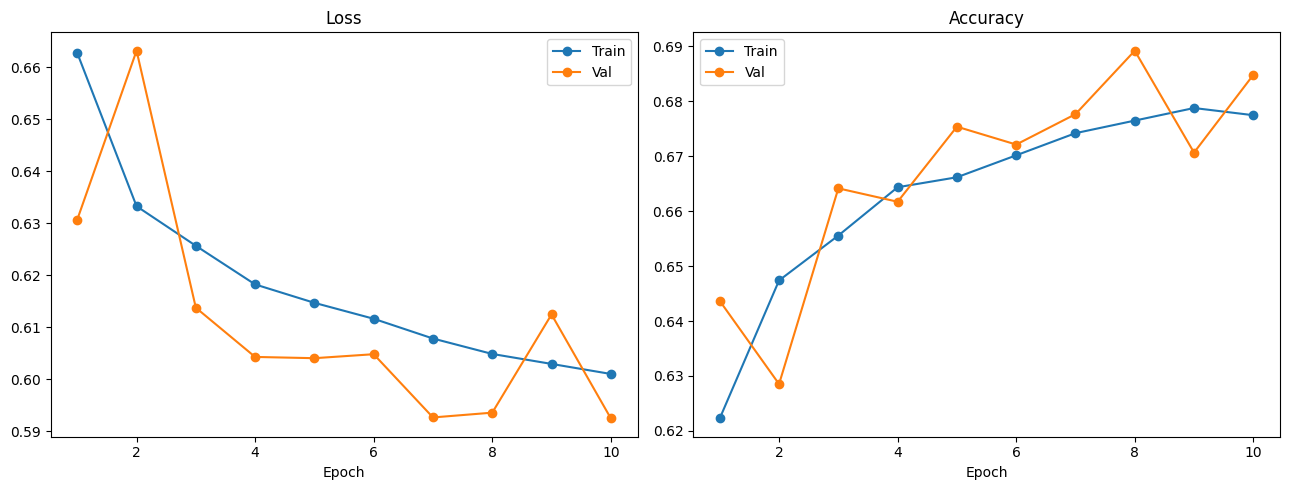

In [15]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o')
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs_ran, history['train_acc'], label='Train', marker='o')
ax2.plot(epochs_ran, history['val_acc'],   label='Val',   marker='o')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## 9. Evaluate on Test Set

In [16]:
# Load best checkpoint
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, pred_probs, true_labels = evaluate(model, test_loader, criterion, DEVICE)
pred_binary = (pred_probs >= 0.5).astype(int)

print(f'Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}\n')
print(classification_report(true_labels.astype(int), pred_binary,
                             target_names=['No Finding', 'Infiltration']))

Test Loss: 0.5875  |  Test Accuracy: 0.6981

              precision    recall  f1-score   support

  No Finding       0.68      0.74      0.71      3039
Infiltration       0.71      0.66      0.69      3036

    accuracy                           0.70      6075
   macro avg       0.70      0.70      0.70      6075
weighted avg       0.70      0.70      0.70      6075



## 10a. Confusion Matrix

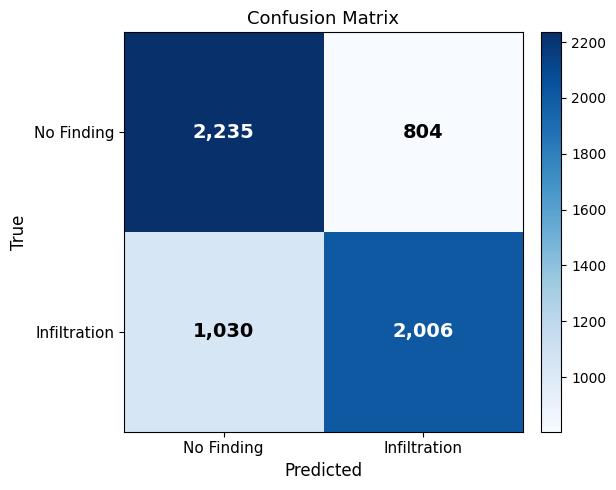


True Negatives  (No Finding   → No Finding):    2235
False Positives (No Finding   → Infiltration):   804
False Negatives (Infiltration → No Finding):    1030
True Positives  (Infiltration → Infiltration):  2006

Sensitivity (Recall):  0.6607
Specificity:           0.7354
Precision:             0.7139


In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(true_labels.astype(int), pred_binary)
# cm[0,0]=TN  cm[0,1]=FP  cm[1,0]=FN  cm[1,1]=TP

CLASS_LABELS = ['No Finding', 'Infiltration']

fig, ax = plt.subplots(figsize=(6, 5))

# Colormap matching the reference image (dark blue = Blues)
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)

# Tick marks and labels
tick_marks = np.arange(len(CLASS_LABELS))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(CLASS_LABELS, fontsize=11)
ax.set_yticklabels(CLASS_LABELS, fontsize=11)

# Axis labels
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13)

# Text annotations — white for dark cells, black for light cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i, j]:,}',
                ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

print(f'\nTrue Negatives  (No Finding   → No Finding):   {cm[0,0]:5d}')
print(f'False Positives (No Finding   → Infiltration): {cm[0,1]:5d}')
print(f'False Negatives (Infiltration → No Finding):   {cm[1,0]:5d}')
print(f'True Positives  (Infiltration → Infiltration): {cm[1,1]:5d}')
print(f'\nSensitivity (Recall):  {cm[1,1] / (cm[1,0] + cm[1,1]):.4f}')
print(f'Specificity:           {cm[0,0] / (cm[0,0] + cm[0,1]):.4f}')
print(f'Precision:             {cm[1,1] / (cm[0,1] + cm[1,1]):.4f}')


## 10. ROC Curve

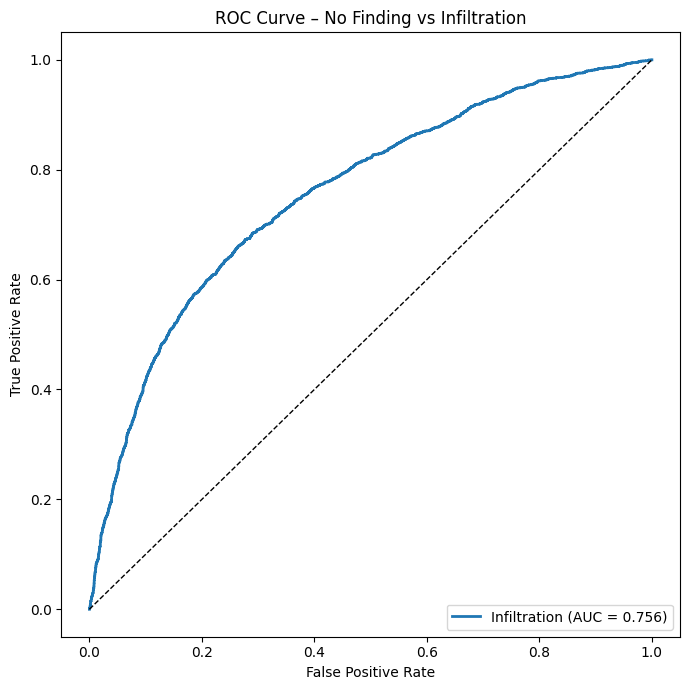

In [18]:
fpr, tpr, _ = roc_curve(true_labels.astype(int), pred_probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, label=f'Infiltration (AUC = {roc_auc:.3f})', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve – No Finding vs Infiltration')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

## 11. Show Predictions on Sample Images

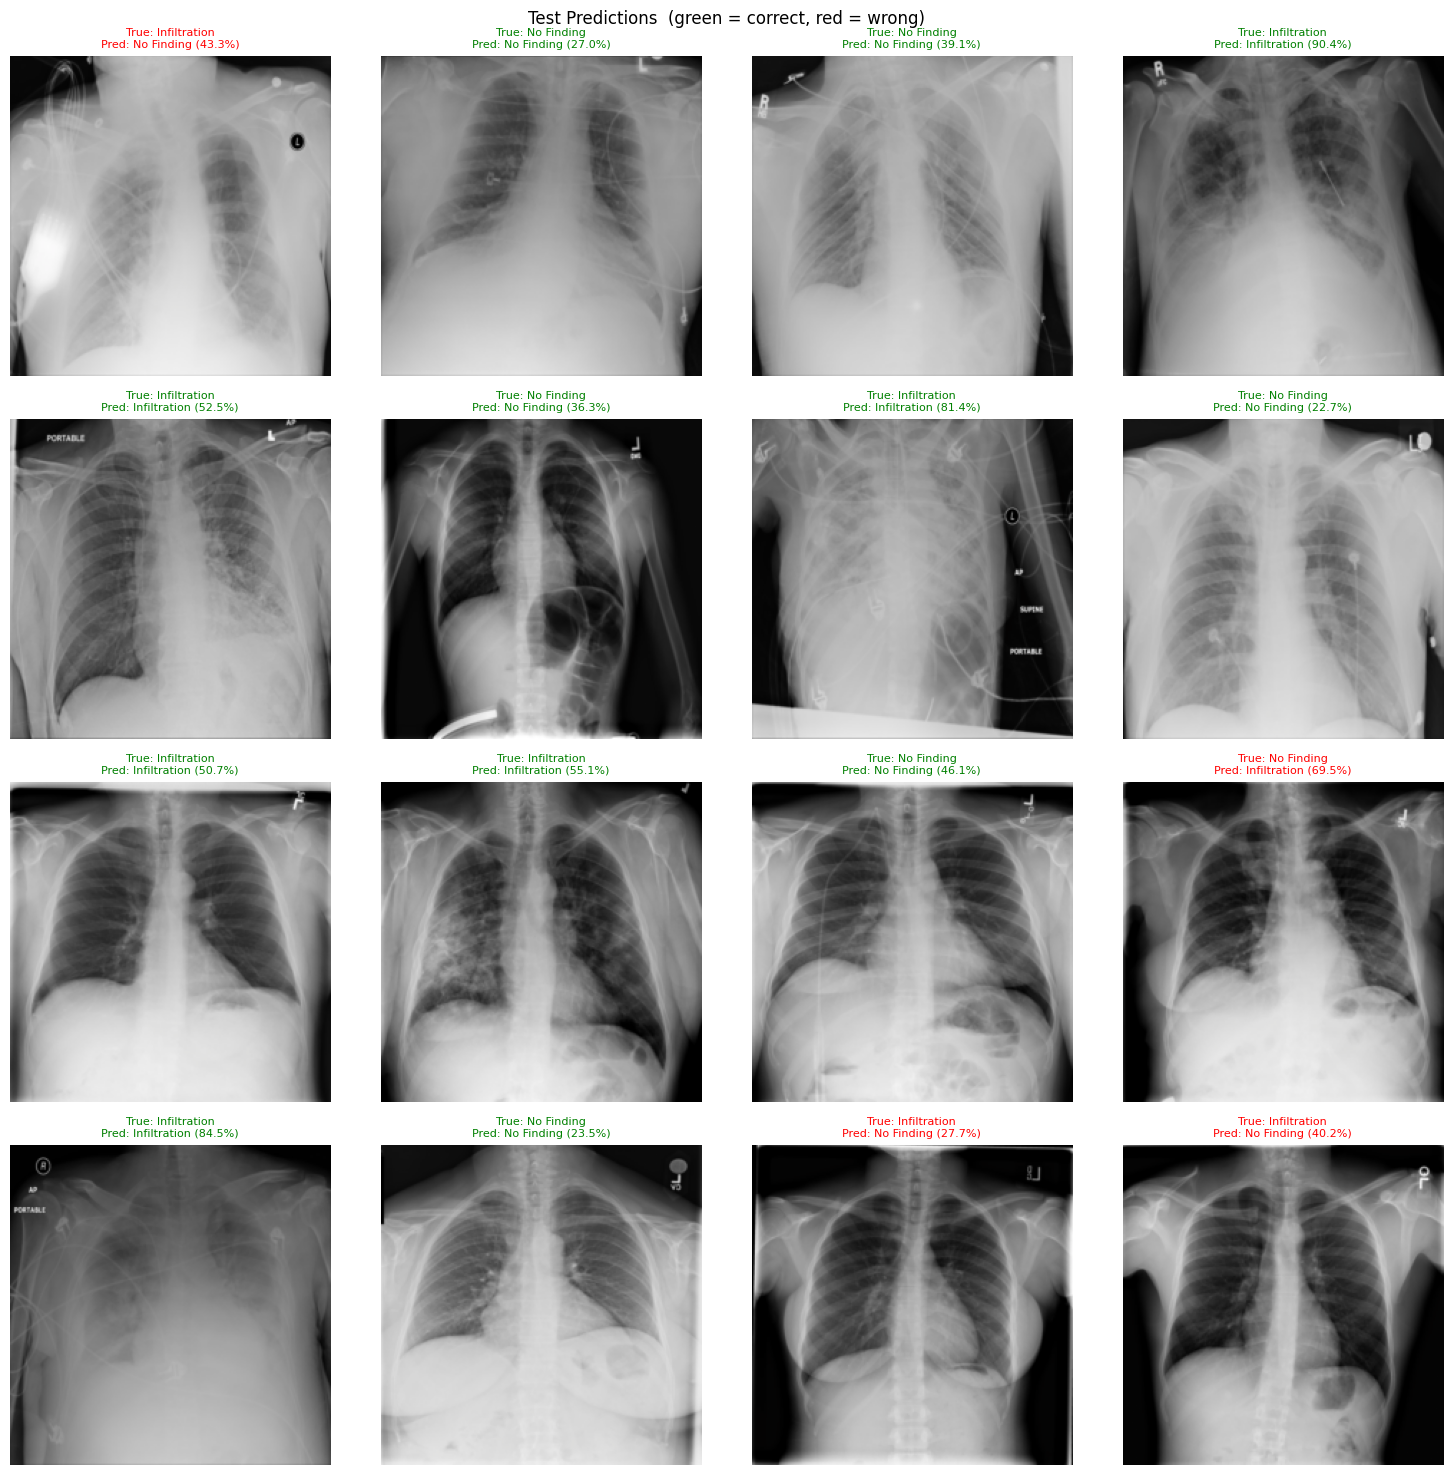

In [19]:
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images_dev = sample_images.to(DEVICE)

with torch.no_grad():
    outputs      = model(sample_images_dev)
    sample_probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # prob of Finding

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

def denormalise(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

for ax, img, true_lbl, prob in zip(axes.flatten(),
                                    sample_images[:n_show],
                                    sample_labels[:n_show],
                                    sample_probs[:n_show]):
    img_np    = denormalise(img).permute(1, 2, 0).numpy()
    pred_lbl  = int(prob >= 0.5)
    true_str  = CLASS_NAMES[int(true_lbl.item())]
    pred_str  = CLASS_NAMES[pred_lbl]
    colour    = 'green' if pred_lbl == int(true_lbl.item()) else 'red'

    ax.imshow(img_np, cmap='bone')
    ax.set_title(f'True: {true_str}\nPred: {pred_str} ({prob:.1%})',
                 color=colour, fontsize=8)
    ax.axis('off')

plt.suptitle('Test Predictions  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=120)
plt.show()

## 12. Save the Final Model

In [20]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names':      CLASS_NAMES,
    'img_size':         IMG_SIZE,
    'n_classes':        N_CLASSES,
    'test_accuracy':    round(test_acc, 4),
    'test_auc':         round(roc_auc, 4),
}, '/kaggle/working/resnet18_xray_final.pth')

print('Model saved to /kaggle/working/resnet18_xray_final.pth')

Model saved to /kaggle/working/resnet18_xray_final.pth
